In [ ]:
import re
import unicodedata
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_PATH = Path.cwd().parent.parent / "data" / "processed" / "version2_new_dataset_fitted.csv"
Path("images").mkdir(exist_ok=True)

In [ ]:
# %% [load shared artifacts from build_parquets]
import pickle
import unicodedata
from joblib import Parallel, delayed
import spacy
from gensim.models.phrases import Phraser
from pathlib import Path

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
PIPELINE_VERSION = "v5_final"
def versioned(path: Path) -> Path:
    return path.with_name(f"{path.stem}_{PIPELINE_VERSION}{path.suffix}")

phraser = Phraser.load(str(versioned(Path("data/bigram_model.pkl"))))
global_counts = pd.read_parquet(versioned(Path("data/global_counts.parquet"))).set_index("lemma")["count"].to_dict()
global_total = sum(global_counts.values())

KEEP_POS = {"NOUN", "ADJ", "VERB", "PROPN"}
MIN_LEMMA_LEN = 4

def strip_accents(text):
    return "".join(
        c for c in unicodedata.normalize("NFD", text)
        if unicodedata.category(c) != "Mn"
    )
CUSTOM_STOPWORDS = {
    "study", "studies", "analysis", "approach", "approaches", "method",
    "methods", "result", "results", "problem", "problems", "application",
    "applications", "using", "based", "paper", "thesis", "research",
    "theory", "case", "system", "systems", "model", "models", "general",
    "certain", "some", "new", "toward", "towards", "note", "notes",
    "essay", "essays",   # add these
}
def tokenize_doc(doc):
    lemmas = [
        tok.lemma_ for tok in doc
        if tok.pos_ in KEEP_POS
        and not tok.is_stop
        and len(tok.lemma_) >= MIN_LEMMA_LEN
        and tok.lemma_ not in CUSTOM_STOPWORDS
    ]
    return phraser[lemmas]

In [89]:
# %% [load]
# Only the columns needed for keyword trends (subject_name kept for readable plot labels).
nodes = pd.read_csv(DATA_PATH, usecols=[
    "thesis", "year", "subject_code", "subject_name",
    "subject_prediction_confidence",
])

nodes["year"] = pd.to_numeric(nodes["year"], errors="coerce")
nodes["subject_code"] = pd.to_numeric(nodes["subject_code"], errors="coerce").astype("Int64")

# Keep only original (human-assigned) subject codes, matching build_parquets
is_original = nodes["subject_code"].notna() & nodes["subject_prediction_confidence"].isna()

# Keep rows that have a title, a year, and an original subject code
df = nodes[is_original].dropna(subset=["thesis", "year"]).copy()
df["year"] = df["year"].astype(int)
df["code"] = df["subject_code"].astype(int).astype(str).str.zfill(2)

# code -> name lookup for plot labels later
code_to_name = (
    df.dropna(subset=["subject_name"])
    .groupby("code")["subject_name"]
    .agg(lambda x: x.mode()[0])
)

print(f"Total rows loaded:        {len(nodes):,}")
print(f"With title + year + original code: {len(df):,}")

Total rows loaded:        338,532
With title + year + original code: 160,548


In [90]:
# %% [language filter] fasttext, batched to dodge the NumPy 2.0 scalar-predict bug
import fasttext
from pathlib import Path

model = fasttext.load_model("lid.176.bin")

# clean titles for detection (keep natural case/accents -- lid.176 needs them)
titles = (
    df["thesis"].astype(str)
    .str.replace("\n", " ", regex=False)
    .str.strip()
    .tolist()
)

# list input -> list of label tuples; avoids the scalar predict path that
# triggers the NumPy 2.0 bug
labels, probs = model.predict(titles)   # labels: list like [('__label__en',), ...]

df["lang_ft"] = [
    lab[0].replace("__label__", "") if lab else "unknown"
    for lab in labels
]
df["is_en_ft"] = df["lang_ft"] == "en"

n_en = int(df["is_en_ft"].sum())
print(f"[fasttext] English:     {n_en:,} ({n_en / len(df):.1%})")
print(f"[fasttext] Non-English: {len(df) - n_en:,} ({1 - n_en / len(df):.1%})")

# %% [filter + cache] English-only analysis set
df_en = df[df["is_en_ft"]].copy()
print(f"Analysis set: {len(df_en):,} English titles")

# cache so the detection pass never has to rerun
out_path = Path("data/keyword_trends_english.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)
# pickle: preserves dtypes 
df_en.to_pickle("data/keyword_trends_english.pkl")
print("Saved to data/keyword_trends_english.pkl")

[fasttext] English:     144,594 (90.1%)
[fasttext] Non-English: 15,954 (9.9%)
Analysis set: 144,594 English titles
Saved to data/keyword_trends_english.pkl


In [91]:
df_en = pd.read_pickle("data/keyword_trends_english.pkl")

Peak year:        2013 (5,174 titles)
START_YEAR:       1954
TREND_END:        2020
Usable titles:    127,229 (88.0% of English set)


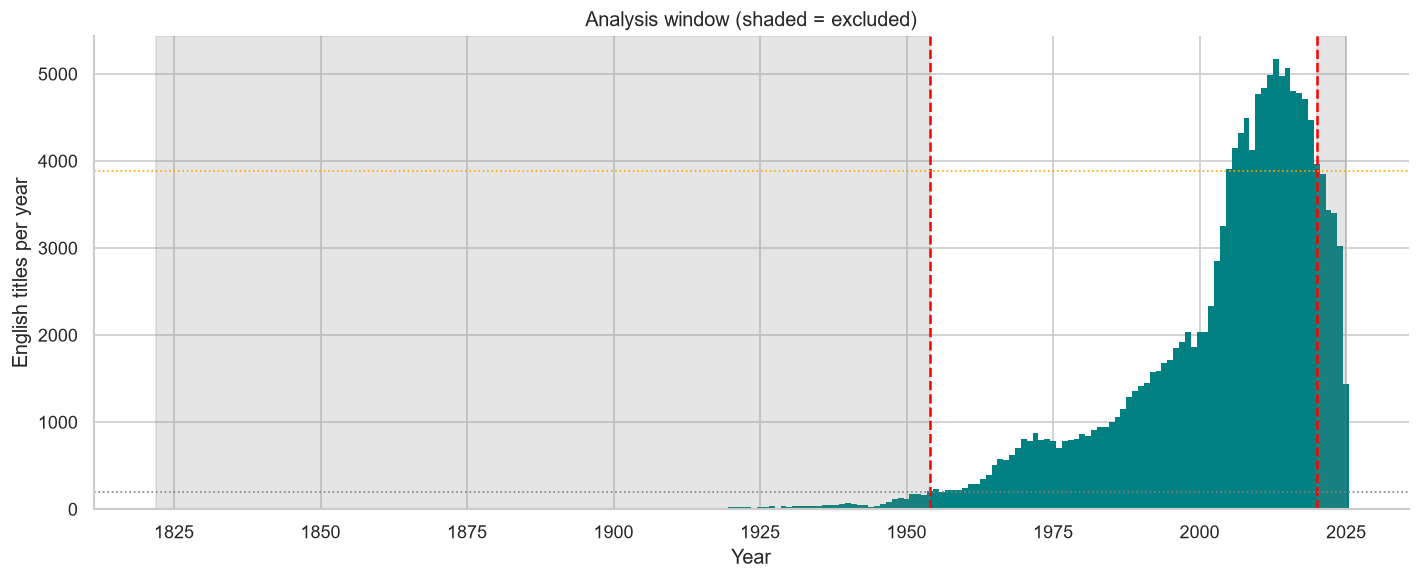

In [92]:
# %% [dynamic year window] derive START_YEAR / TREND_END from the English data
# Rules, not magic numbers:
#   START_YEAR = first year with enough titles for a stable yearly share
#   TREND_END  = last year before the data-entry lag drop-off

MIN_TITLES_PER_YEAR = 200    # floor for a usable year
LAG_DROP_FRAC       = 0.75   # cut tail once counts fall below this fraction of peak

per_year = (
    df_en.assign(year=lambda d: d["year"].astype(int))
    .query("1800 <= year <= 2025")
    .groupby("year")
    .size()
    .sort_index()
)

# START_YEAR: first year at or above the floor
START_YEAR = int(per_year[per_year >= MIN_TITLES_PER_YEAR].index.min())

# TREND_END: walk forward from the peak, keep years still above the lag threshold
peak_year = int(per_year.idxmax())
peak_val  = int(per_year.max())
tail = per_year[per_year.index >= peak_year]
TREND_END = int(tail[tail >= LAG_DROP_FRAC * peak_val].index.max())

usable = per_year[(per_year.index >= START_YEAR) & (per_year.index <= TREND_END)]
print(f"Peak year:        {peak_year} ({peak_val:,} titles)")
print(f"START_YEAR:       {START_YEAR}")
print(f"TREND_END:        {TREND_END}")
print(f"Usable titles:    {usable.sum():,} ({usable.sum() / len(df_en):.1%} of English set)")

# %% [plot] derived window on the full curve
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(per_year.index, per_year.values, color="teal", edgecolor="none", width=1.0)
ax.axvline(START_YEAR, color="red", linestyle="--", linewidth=1.5)
ax.axvline(TREND_END, color="red", linestyle="--", linewidth=1.5)
ax.axhline(MIN_TITLES_PER_YEAR, color="gray", linestyle=":", linewidth=1)
ax.axhline(LAG_DROP_FRAC * peak_val, color="orange", linestyle=":", linewidth=1)
ax.axvspan(per_year.index.min(), START_YEAR, color="gray", alpha=0.2)
ax.axvspan(TREND_END, per_year.index.max(), color="gray", alpha=0.2)
ax.set_xlabel("Year")
ax.set_ylabel("English titles per year")
ax.set_title("Analysis window (shaded = excluded)")
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("images/year_window_derivation.png", dpi=150, bbox_inches="tight")
plt.show()

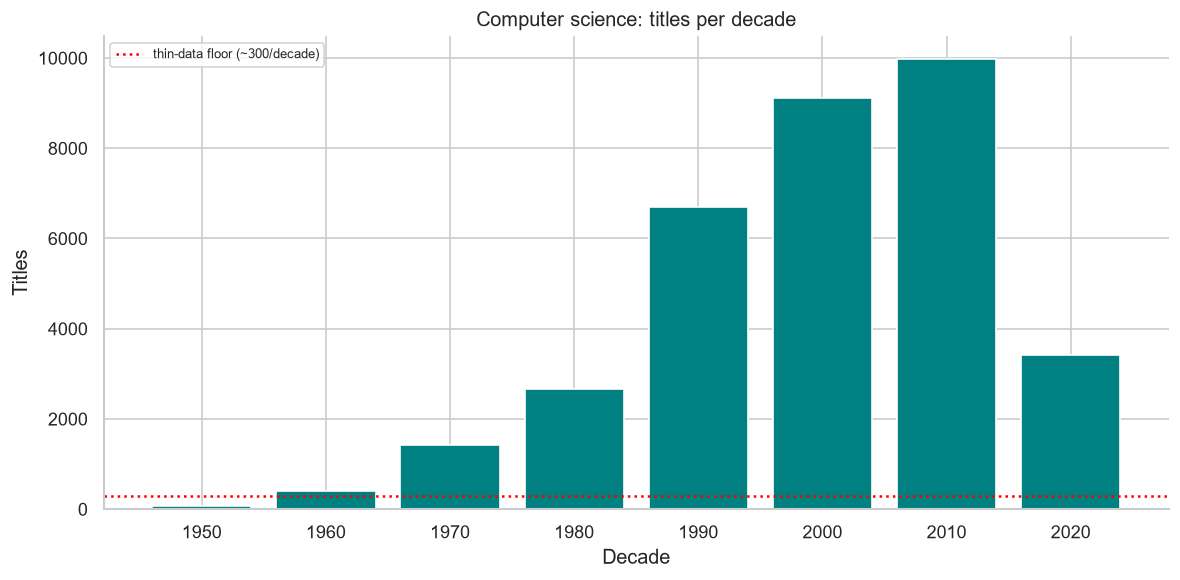

In [74]:
# %% per-subject usable window: volume + word-share stability (decade bins)
SUBJECT = "68"


sub = (
    df_en[df_en["code"] == SUBJECT]
    .assign(
        year=lambda d: d["year"].astype(int),
        decade=lambda d: (d["year"] // 10 * 10)
    )
    .query("1950 <= year <= 2024")
)

sub_per_decade = sub.groupby("decade").size()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(sub_per_decade.index, sub_per_decade.values, width=8, color="teal")
ax.axhline(300, color="red", linestyle=":", label="thin-data floor (~300/decade)")
subj_name = code_to_name.get(SUBJECT, SUBJECT)
ax.set_title(f"{subj_name}: titles per decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Titles")
ax.legend(fontsize=8)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("images/subject_volume_by_decade.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
# tunable parameters
START_YEAR   = 1950   # before this, titles are too sparse to trust shares
TREND_END    = 2020  # cut the post-2020 data-entry lag tail
MIN_TOTAL    = 300    # min total occurrences for a word to be considered
RECENT       = 10     # length of the recent window for the slope (years)
MIN_RECENT_N = 50     # min occurrences inside the recent window to trust the slope
MIN_WORD_LEN = 4      # token regex length floor; raising cuts more short filler
TOP_K        = 15     # how many rising words to show

In [31]:
#!pip install spacy
#!pip install click
#!python -m spacy download en_core_web_sm


In [75]:
# %% [per-subject rising-word detection]
MIN_TOTAL      = 10
TREND_END      = 2024
RECENT         = 10
SPECIFICITY    = 1.5   # word must appear 1.5x more in subject than globally
SUBJECT        = "68"

sub_df = df_en[df_en["code"] == SUBJECT].reset_index(drop=True)

titles_clean = [strip_accents(str(t).lower()) for t in sub_df["thesis"]]
years_list   = sub_df["year"].tolist()

year_word, year_total = {}, {}
for year, doc in zip(years_list, nlp.pipe(titles_clean, batch_size=512, n_process=1)):
    toks = tokenize_doc(doc)
    year_word.setdefault(year, Counter()).update(toks)
    year_total[year] = year_total.get(year, 0) + len(toks)

overall = Counter()
for c in year_word.values():
    overall.update(c)

subject_total_words = sum(year_total.values())

def is_specific(word, count):
    subject_share = count / max(subject_total_words, 1)
    global_share  = global_counts.get(word, 0) / max(global_total, 1)
    return (subject_share / max(global_share, 1e-9)) >= SPECIFICITY

common_words = {
    w for w, n in overall.items()
    if n >= MIN_TOTAL and is_specific(w, n)
}
print(f"Subject {SUBJECT}: {len(common_words)} specific words above MIN_TOTAL")

recent_years = [
    y for y in range(TREND_END - RECENT + 1, TREND_END + 1)
    if year_total.get(y, 0) > 0
]

def score_word(w):
    shares = [year_word[y].get(w, 0) / year_total[y] for y in recent_years]
    if len(shares) < 5:
        return None
    slope = np.polyfit(range(len(shares)), shares, 1)[0] * 10 * 100
    return {"word": w, "recent_slope": slope, "total": overall[w]}

rows = Parallel(n_jobs=-1, prefer="threads")(
    delayed(score_word)(w) for w in common_words
)

rising = (
    pd.DataFrame([r for r in rows if r is not None])
    .dropna()
    .query("recent_slope > 0")
    .nlargest(15, "recent_slope")
)

print(rising.round(3).to_string(index=False))

Subject 68: 1143 specific words above MIN_TOTAL
                   word  recent_slope  total
       machine_learning         0.898    375
          deep_learning         0.794    197
               learning         0.762    712
         neural_network         0.491    301
 reinforcement_learning         0.328    152
                  learn         0.314    775
          machine_learn         0.297    164
              algorithm         0.276   2392
              efficient         0.271   1190
                   deep         0.266    125
                explore         0.232    126
            explainable         0.230     29
artificial_intelligence         0.227     79
                 neural         0.215    117
             multimodal         0.176     60


In [78]:
# after building `rising`, post-process in two steps

# 1. deduplicate lemma variants: if word A is a prefix of word B and both appear,
#    keep whichever has higher total count
def deduplicate_lemmas(df):
    words_by_total = df.sort_values("total", ascending=False)["word"].tolist()
    keep = []
    for w in words_by_total:
        dominated = any(
            w.startswith(kept) or kept.startswith(w)
            for kept in keep
        )
        if not dominated:
            keep.append(w)
    return df[df["word"].isin(keep)]

# 2. drop words above a global frequency ceiling
#    these are too common corpus-wide to be meaningful signals
MAX_GLOBAL_SHARE = 0.05   # word appears in >0.5% of ALL title words = generic

def below_global_ceiling(word):
    return (global_counts.get(word, 0) / global_total) < MAX_GLOBAL_SHARE

rising = (
    pd.DataFrame([r for r in rows if r is not None])
    .dropna()
    .query("recent_slope > 0")
    .pipe(deduplicate_lemmas)
    .loc[lambda d: d["word"].map(below_global_ceiling)]
    .nlargest(15, "recent_slope")
)

print(rising.round(3).to_string(index=False))

                   word  recent_slope  total
          deep_learning         0.794    197
         neural_network         0.491    301
 reinforcement_learning         0.328    152
                  learn         0.314    775
              algorithm         0.276   2392
              efficient         0.271   1190
                explore         0.232    126
            explainable         0.230     29
artificial_intelligence         0.227     79
             multimodal         0.176     60
              knowledge         0.174    616
                enhance         0.168    193
             generative         0.160     63
                   task         0.159    275
               leverage         0.152     77


In [79]:
# score = recent_slope * specificity_ratio / log(global_frequency)
# words that are both generic AND not specific get buried

def enriched_score(word, slope, count):
    subject_share = count / max(subject_total_words, 1)
    global_share = global_counts.get(word, 0) / max(global_total, 1)
    specificity   = subject_share / max(global_share, 1e-9)
    penalty       = np.log1p(global_counts.get(word, 0))   # higher global count = more penalty
    return slope * specificity / penalty

rows_scored = Parallel(n_jobs=-1, prefer="threads")(
    delayed(score_word)(w) for w in common_words
)

rising = (
    pd.DataFrame([r for r in rows_scored if r is not None])
    .dropna()
    .query("recent_slope > 0")
    .pipe(deduplicate_lemmas)
    .assign(enriched=lambda d: d.apply(
        lambda r: enriched_score(r["word"], r["recent_slope"], r["total"]), axis=1
    ))
    .nlargest(15, "enriched")   # rank by enriched score, not raw slope
)

print(rising[["word", "recent_slope", "total", "enriched"]].round(3).to_string(index=False))

                   word  recent_slope  total  enriched
          deep_learning         0.794    197     0.451
artificial_intelligence         0.227     79     0.267
            explainable         0.230     29     0.257
         neural_network         0.491    301     0.224
 reinforcement_learning         0.328    152     0.201
             multimodal         0.176     60     0.149
             generative         0.160     63     0.144
             multiparty         0.104     33     0.138
                  learn         0.314    775     0.130
         internet_thing         0.103     40     0.126
            deep_neural         0.138     55     0.117
              efficient         0.271   1190     0.116
                   task         0.159    275     0.103
             blockchain         0.121     31     0.101
              algorithm         0.276   2392     0.097


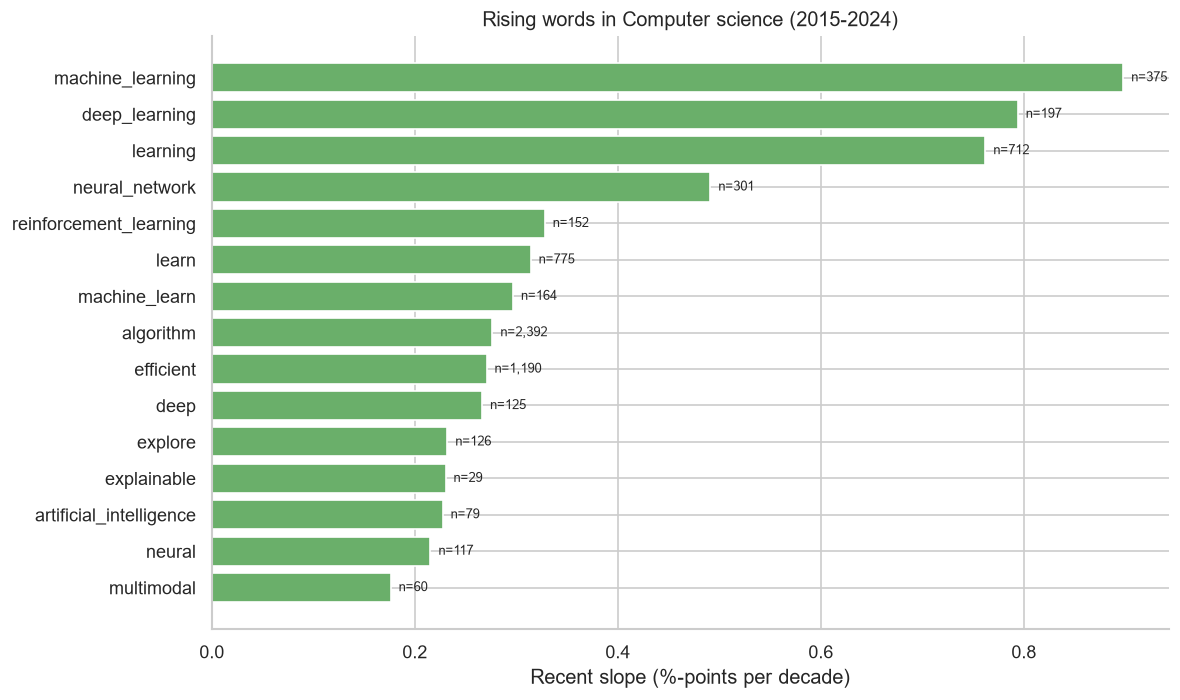

In [77]:
# %% [plot rising words]
fig, ax = plt.subplots(figsize=(10, 6))
d = rising.sort_values("recent_slope")
ax.barh(d["word"], d["recent_slope"], color="#6aaf6a", edgecolor="white")
for i, (_, r) in enumerate(d.iterrows()):
    ax.text(r["recent_slope"], i, f"  n={int(r['total']):,}", va="center", fontsize=8)
ax.set_xlabel("Recent slope (%-points per decade)")
subj_name = code_to_name.get(SUBJECT, SUBJECT) 
ax.set_title(f"Rising words in {subj_name} ({recent_years[0]}-{TREND_END})")
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f"images/rising_words_barh_subject{SUBJECT}.png", dpi=150, bbox_inches="tight")
plt.show()

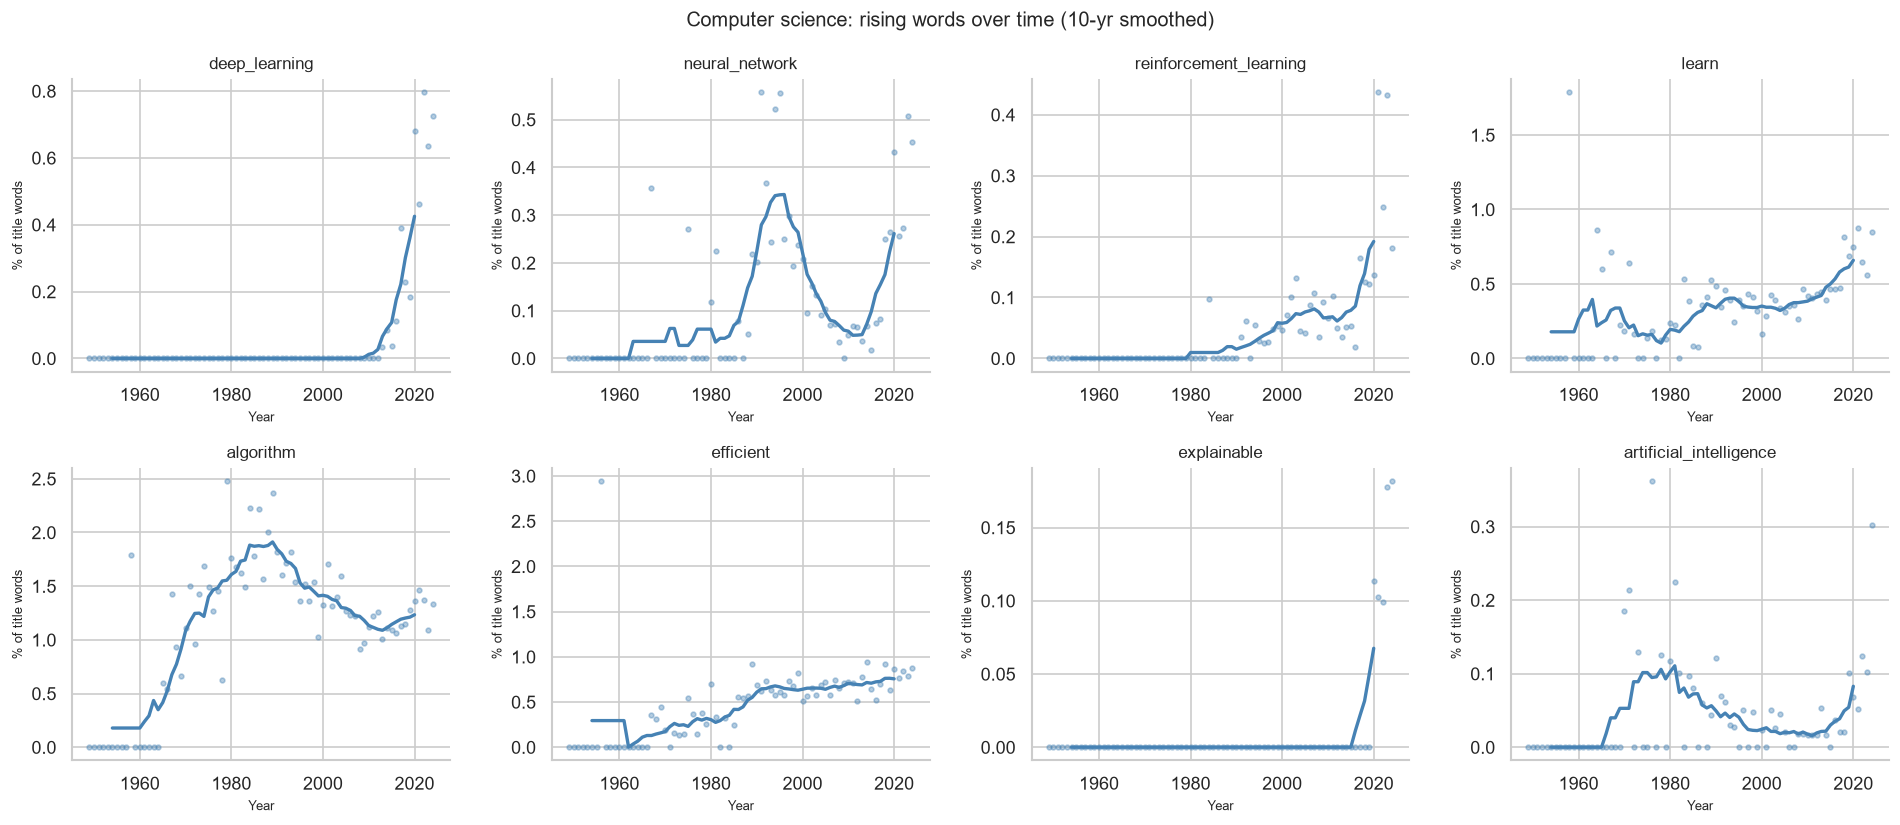

In [81]:
# %% [plot] time series for top rising words in subject SUBJECT
TOP_N = 8
top_words = rising.nlargest(TOP_N, "recent_slope")["word"].tolist()

all_years = sorted(y for y in year_word if START_YEAR <= y <= TREND_END)

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()

for ax, word in zip(axes, top_words):
    shares = [
        year_word[y].get(word, 0) / max(year_total[y], 1) * 100
        for y in all_years
    ]
    smoothed = pd.Series(shares, index=all_years).rolling(10, center=True).mean()
    ax.plot(all_years, smoothed, linewidth=2, color="steelblue")
    ax.scatter(all_years, shares, s=8, alpha=0.4, color="steelblue")
    ax.set_title(word, fontsize=10)
    ax.set_xlabel("Year", fontsize=8)
    ax.set_ylabel("% of title words", fontsize=8)
    sns.despine(ax=ax)
subj_name = code_to_name.get(SUBJECT, SUBJECT) 
fig.suptitle(f"{subj_name}: rising words over time (10-yr smoothed)", fontsize=12)
plt.tight_layout()
plt.savefig(f"images/rising_words_timeseries_subject{SUBJECT}.png", dpi=150, bbox_inches="tight")
plt.show()

In [60]:
# %% [multi-subject rising word detection]
import pickle

all_subjects = df_en["code"].dropna().unique().tolist()
all_results  = []

for subject in all_subjects:
    sub_df = df_en[df_en["code"] == subject].reset_index(drop=True)
    if len(sub_df) < 100:
        continue

    # load precomputed counts from build_parquets instead of re-tokenizing
    pkl_path = Path("data/subject_counts") / f"{subject}.pkl"
    if not pkl_path.exists():
        print(f"Skipping {subject} -- pkl not found, build_parquets may still be running")
        continue

    with open(pkl_path, "rb") as f:
        counts = pickle.load(f)
    year_word  = counts["year_word"]
    year_total = counts["year_total"]

    overall = Counter()
    for c in year_word.values():
        overall.update(c)

    subject_total_words = sum(year_total.values())

    common_words = {
        w for w, n in overall.items()
        if n >= MIN_TOTAL and is_specific(w, n)
    }

    recent_years = [
        y for y in range(TREND_END - RECENT + 1, TREND_END + 1)
        if year_total.get(y, 0) > 0
    ]

    def score_word(w):
        shares = [year_word[y].get(w, 0) / year_total[y] for y in recent_years]
        if len(shares) < 5:
            return None
        slope = np.polyfit(range(len(shares)), shares, 1)[0] * 10 * 100
        gc = global_counts.get(w, 0)
        spec = (overall[w] / max(subject_total_words, 1)) / max(gc / global_total, 1e-9)
        enr  = slope * spec / np.log1p(gc)
        return {"subject": subject, "word": w, "recent_slope": slope,
                "total": overall[w], "enriched": enr}

    rows = Parallel(n_jobs=-1, prefer="threads")(
        delayed(score_word)(w) for w in common_words
    )

    subject_rising = (
        pd.DataFrame([r for r in rows if r is not None])
        .dropna()
        .query("recent_slope > 0")
        .pipe(deduplicate_lemmas)
        .nlargest(10, "enriched")
    )
    subject_rising["subject_name"] = code_to_name.get(subject, subject)
    all_results.append(subject_rising)

results_df = pd.concat(all_results, ignore_index=True)
results_df.to_parquet("data/rising_words_all_subjects.parquet")
print(f"Done: {len(results_df)} rising words across {results_df['subject'].nunique()} subjects")

C:\Users\Work\AppData\Local\Temp\ipykernel_32068\2550745820.py:46: RuntimeWarning: divide by zero encountered in scalar divide
  enr  = slope * spec / np.log1p(gc)
C:\Users\Work\AppData\Local\Temp\ipykernel_32068\2550745820.py:46: RuntimeWarning: divide by zero encountered in scalar divide
  enr  = slope * spec / np.log1p(gc)
C:\Users\Work\AppData\Local\Temp\ipykernel_32068\2550745820.py:46: RuntimeWarning: divide by zero encountered in scalar divide
  enr  = slope * spec / np.log1p(gc)
C:\Users\Work\AppData\Local\Temp\ipykernel_32068\2550745820.py:46: RuntimeWarning: divide by zero encountered in scalar divide
  enr  = slope * spec / np.log1p(gc)
C:\Users\Work\AppData\Local\Temp\ipykernel_32068\2550745820.py:46: RuntimeWarning: divide by zero encountered in scalar divide
  enr  = slope * spec / np.log1p(gc)


Done: 540 rising words across 62 subjects


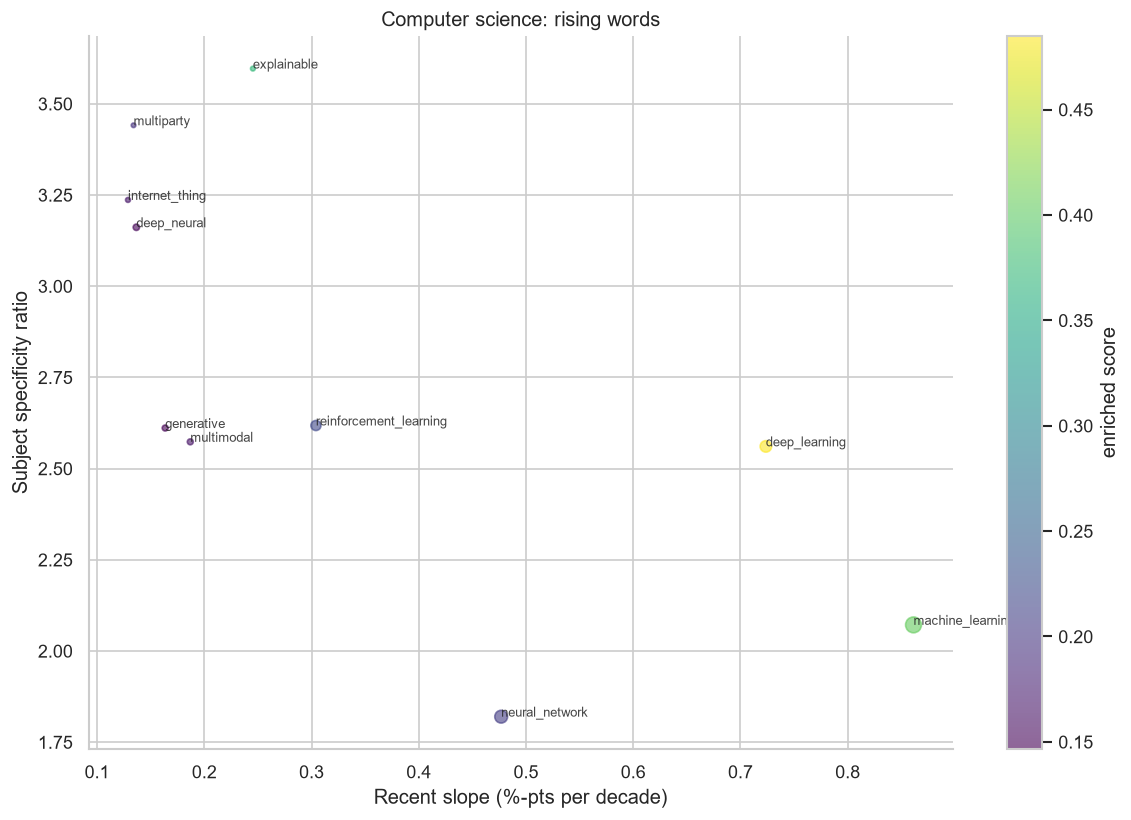

In [84]:
# %% [bubble chart for one subject]
SUBJECT = "68"
sub = results_df[results_df["subject"] == SUBJECT].copy()
sub["specificity"] = sub.apply(
    lambda r: (r["total"] / subject_total_words) / max(global_counts[r["word"]] / global_total, 1e-9),
    axis=1
)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(sub["recent_slope"], sub["specificity"],
                s=sub["total"] * 0.3, alpha=0.6, c=sub["enriched"], cmap="viridis")
for _, row in sub.iterrows():
    ax.annotate(row["word"], (row["recent_slope"], row["specificity"]),
                fontsize=8, alpha=0.85)
plt.colorbar(sc, ax=ax, label="enriched score")
ax.set_xlabel("Recent slope (%-pts per decade)")
ax.set_ylabel("Subject specificity ratio")
ax.set_title(f"{subj_name}: rising words") 
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f"images/bubble_subject{SUBJECT}.png", dpi=150, bbox_inches="tight")
plt.show()

Showing 15 subjects by title volume


C:\Users\Work\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
C:\Users\Work\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


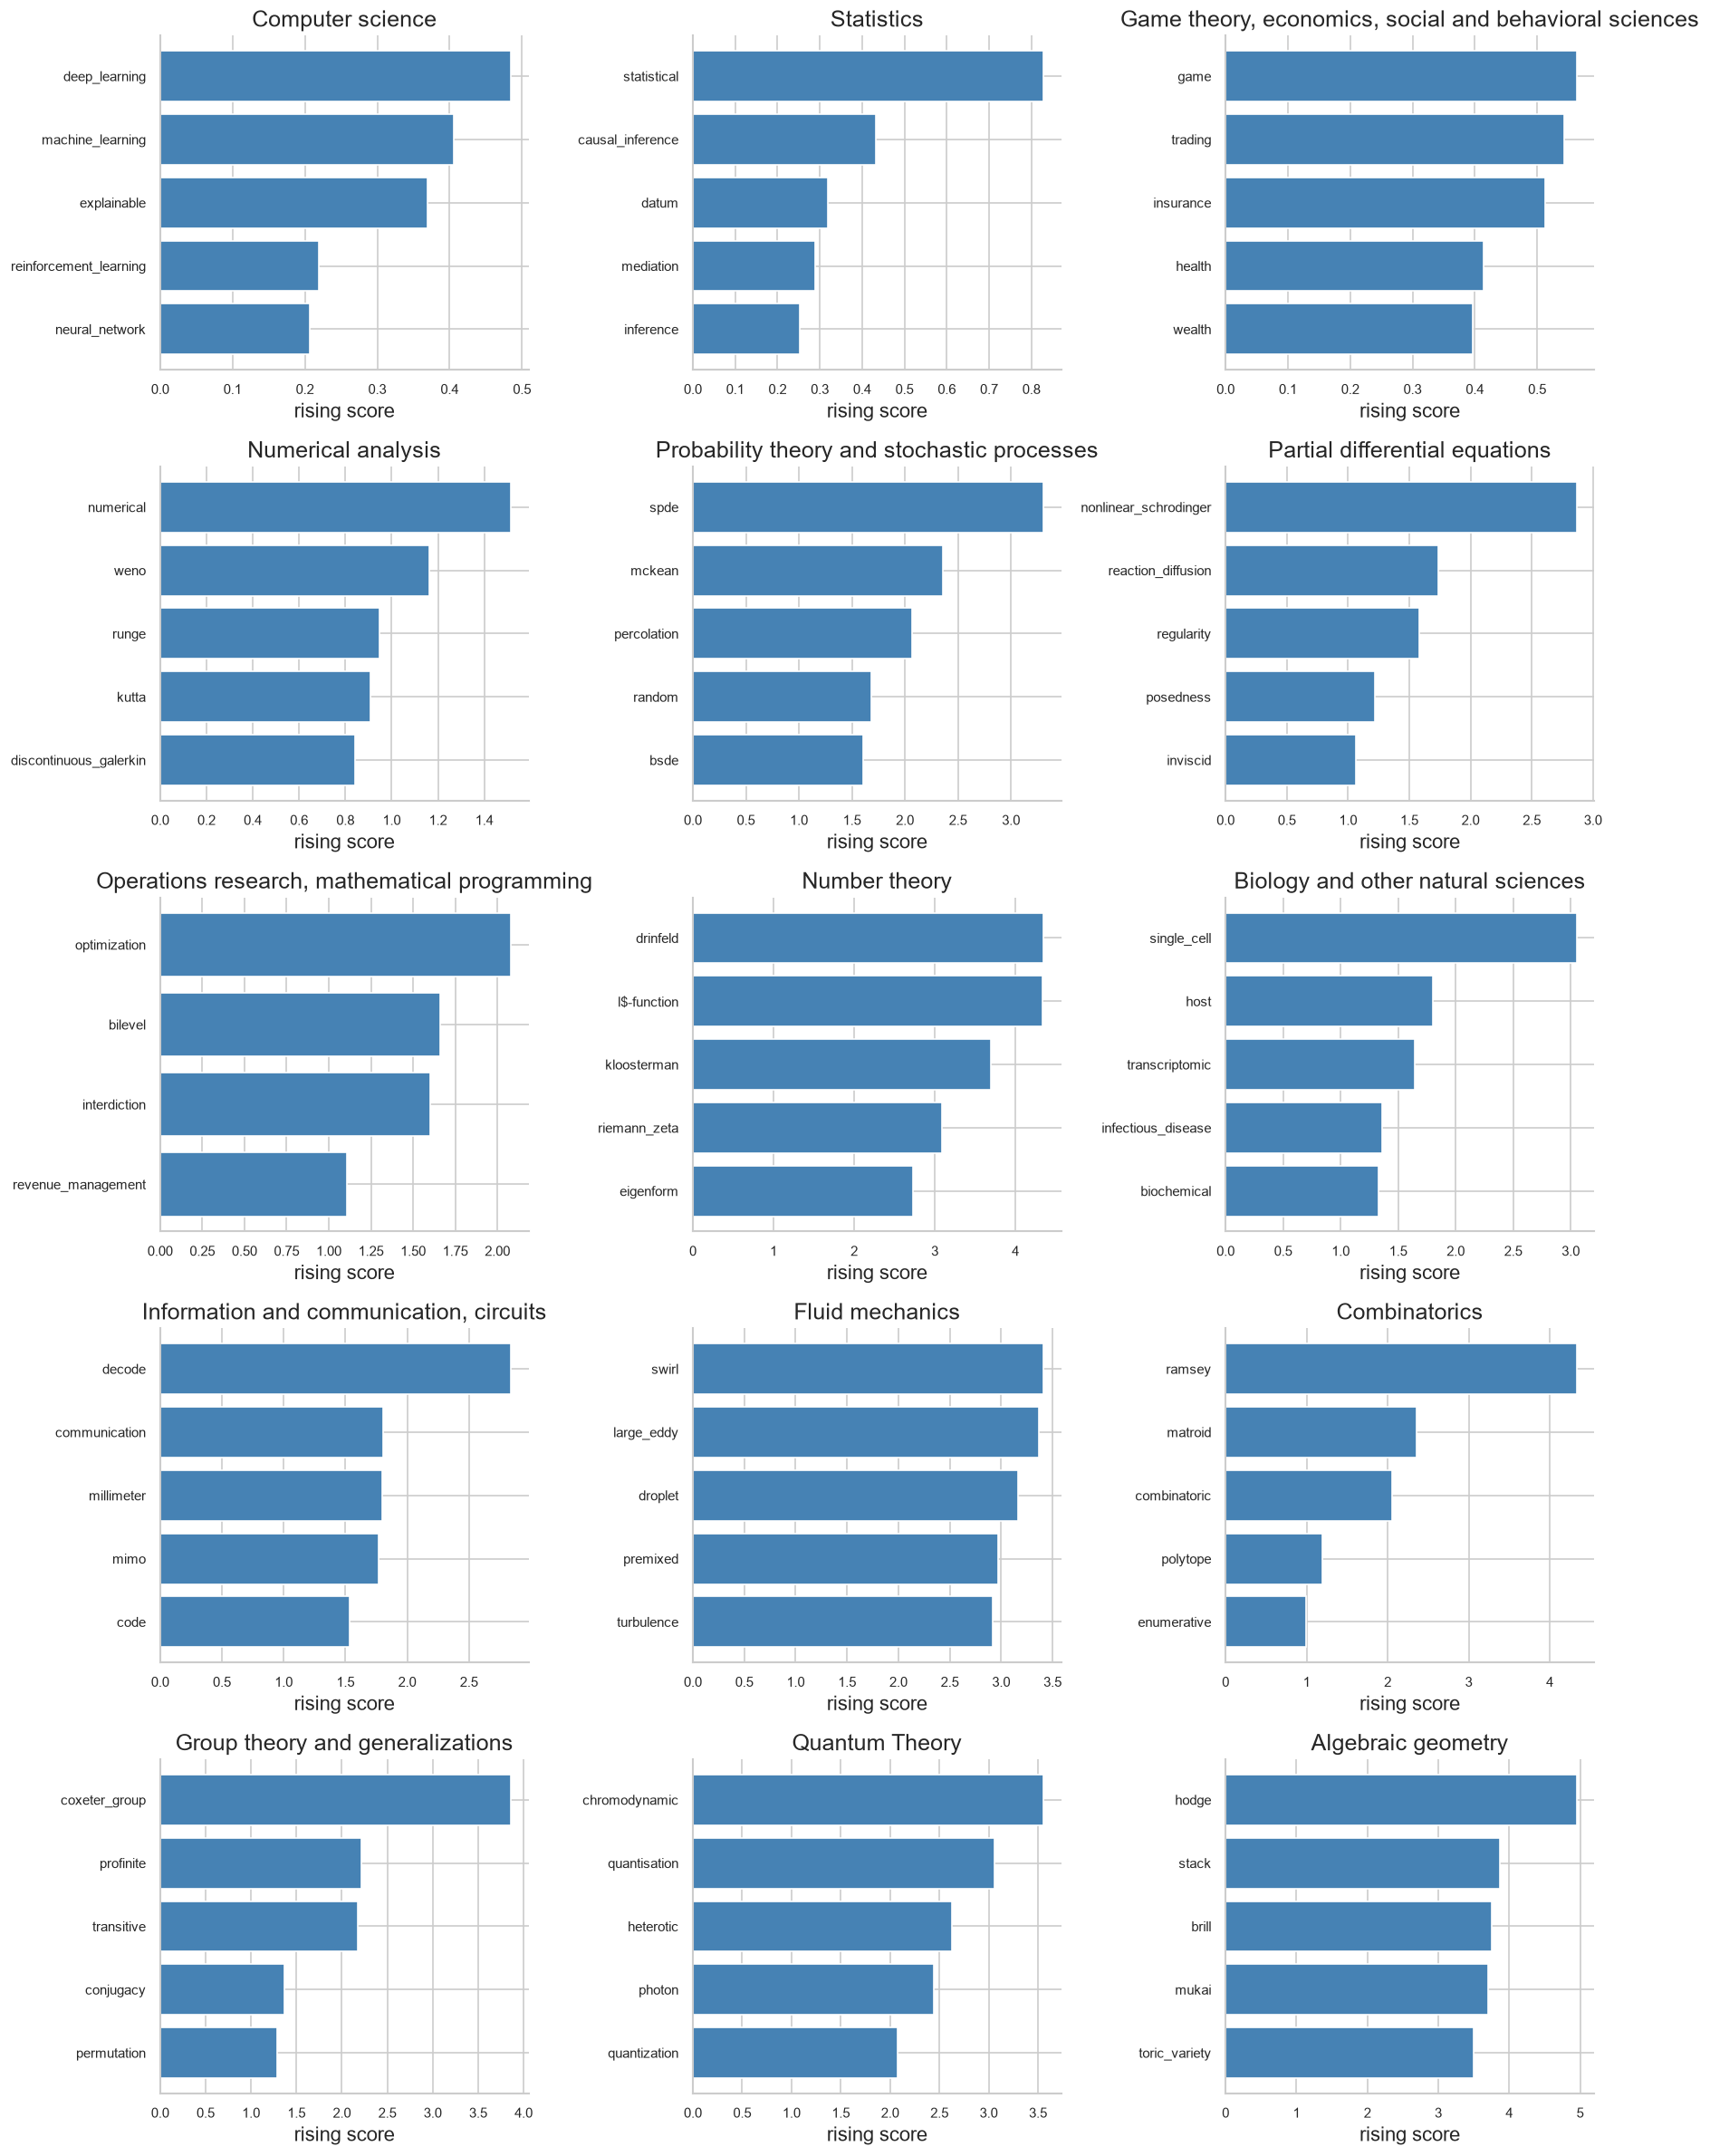

In [88]:
# %% [small multiples: top 5 words in subjects with most titles]
TOP_SUBJECTS = 15  # matches the 15 in your model_v2 pattern, adjust if you want fewer

subject_title_counts = (
    df_en.groupby("code")
    .size()
    .rename("n_titles")
    .reset_index()
)
subject_title_counts["subject_name"] = subject_title_counts["code"].map(code_to_name)

good_subjects = (
    subject_title_counts
    .nlargest(TOP_SUBJECTS, "n_titles")["subject_name"]
    .tolist()
)

print(f"Showing {len(good_subjects)} subjects by title volume")

ncols = 3
nrows = -(-len(good_subjects) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for ax, subj in zip(axes, good_subjects):
    sub = (results_df[results_df["subject_name"] == subj]
           .nlargest(5, "enriched")
           .sort_values("enriched"))
    ax.barh(sub["word"], sub["enriched"], color="steelblue")
    ax.set_title(subj, fontsize=15)
    ax.set_xlabel("rising score", fontsize=13)
    ax.tick_params(labelsize=9)
    sns.despine(ax=ax)
for ax in axes[len(good_subjects):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("images/top15_subjects_rising_words.png", dpi=150, bbox_inches="tight")
plt.show()